# 9. From Communication to Computation

Congratulations! You have journeyed from the fundamental properties of single qubits to the spooky phenomenon of entanglement and its applications in teleportation and superdense coding. But where do we go from here?

So far, we have largely looked at "protocols"—methods to move information around. The next major leap is **Quantum Computation**: processing information to solve problems that are intractable for classical computers.

In this outlook, we will explore two pillars that define the future of this technology:
1.  **Oracle-Based Algorithms:** How we use superposition to "query" all answers at once.
2.  **Quantum Error Correction:** How we build reliable computers out of unreliable parts.

## 9.1. The Power of the Oracle
Many quantum algorithms are phrased in terms of an **Oracle**—a quantum "black box" subroutine. Suppose you have a function $f(x)$. A classical computer must evaluate $f(x)$ for every input $x$ to learn about the function's global properties.

A quantum computer can prepare a superposition of *all* inputs:
$$\sum |x\rangle$$
And apply the oracle to this superposition to get:
$$\sum |x\rangle|f(x)\rangle$$
By using **Interference**, we can then cancel out the wrong answers and amplify the correct ones. This is the core principle behind **Grover's Search Algorithm** (finding a needle in a haystack) and **Shor's Algorithm** (breaking encryption).

## 9.2. The Deutsch Algorithm

Many quantum algorithms are phrased in terms of an **Oracle**—a quantum "black box" subroutine. Suppose we have a function $f(x)$ that takes a single bit input ($0$ or $1$) and outputs a single bit ($0$ or $1$).

There are only 4 possible functions like this:
1.  **Constant:** $f(0) = 0, f(1) = 0$ (Output is always 0)
2.  **Constant:** $f(0) = 1, f(1) = 1$ (Output is always 1)
3.  **Balanced:** $f(0) = 0, f(1) = 1$ (Identity)
4.  **Balanced:** $f(0) = 1, f(1) = 0$ (Bit flip)

**The Problem:** You are given a black box (oracle) containing one of these functions. You want to know: **Is the function Constant or Balanced?**

* **Classically:** You must query the box twice. You calculate $f(0)$, then calculate $f(1)$, and compare them.
* **Quantumly (Deutsch Algorithm):** You can determine this property with **only one query**.

### How it works
The algorithm uses interference. We prepare the input state in a superposition $|+\rangle$ and the target qubit in the state $|-\rangle$.
When the oracle applies the function, the "answer" is kicked back into the phase of the input qubit due to the unique properties of the $|-\rangle$ state (Phase Kickback).

* If the function is **Constant**, the phase remains unchanged. Measurement yields **0**.
* If the function is **Balanced**, the phase flips. Measurement yields **1**.

--- Batch Testing ---
Oracle: Constant 0           | Result: 0 | Conclusion: Constant
Oracle: Constant 1           | Result: 0 | Conclusion: Constant
Oracle: Balanced Identity    | Result: 1 | Conclusion: Balanced
Oracle: Balanced Flip        | Result: 1 | Conclusion: Balanced

VISUALIZATION DEEP DIVE: Balanced Flip
Notice how the phase kickback in Step 2 changes the rotation of the left gauge lines

--- Step 1: Initialization (|+>|->) ---


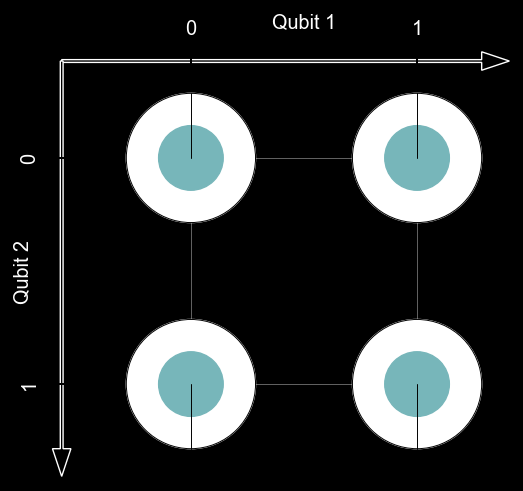

--- Step 2: After Oracle (Balanced Flip) ---


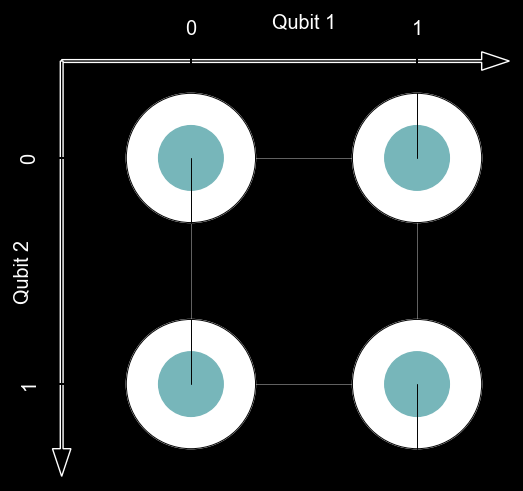

--- Step 3: Final State (Before Measurement) ---


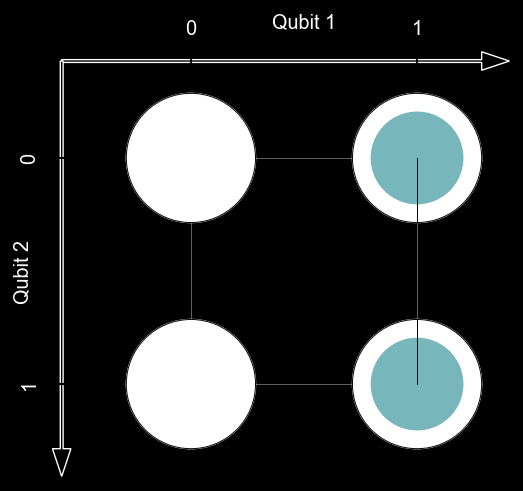

Oracle: Balanced Flip        | Result: 1 | Conclusion: Balanced


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Custom Visualization
from qc_education_package import DimensionalCircleNotation

def get_oracle(type_str):
    """Returns a 2-qubit QuantumCircuit implementing an oracle function."""
    qc = QuantumCircuit(2)
    if type_str == "Constant 0": pass
    elif type_str == "Constant 1": qc.x(1)
    elif type_str == "Balanced Identity": qc.cx(0, 1)
    elif type_str == "Balanced Flip":
        qc.cx(0, 1)
        qc.x(1)
    else: raise ValueError("Unknown oracle type")

    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle: " + type_str
    return oracle_gate

def run_deutsch_algorithm(oracle_type, visualize=False):
    # 1. Initialize Circuit
    qc = QuantumCircuit(2, 1)

    # 2. Prepare States (|0>|1>) -> (|+>|->)
    qc.x(1)
    qc.h(0)
    qc.h(1)

    if visualize:
        print(f"\n--- Step 1: Initialization (|+>|->) ---")
        DimensionalCircleNotation.from_qiskit(qc).show()

    qc.barrier()

    # 3. Apply the Oracle
    oracle = get_oracle(oracle_type)
    qc.append(oracle, [0, 1])

    if visualize:
        print(f"--- Step 2: After Oracle ({oracle_type}) ---")
        # We must decompose the custom oracle gate for the visualizer to understand it
        qc_vis = qc.decompose()
        DimensionalCircleNotation.from_qiskit(qc_vis).show()

    qc.barrier()

    # 4. Interference (Final H on Input)
    qc.h(0)

    if visualize:
        print(f"--- Step 3: Final State (Before Measurement) ---")
        # Decompose again to be safe
        qc_vis = qc.decompose()
        DimensionalCircleNotation.from_qiskit(qc_vis).show()

    # 5. Measure Input Qubit
    qc.measure(0, 0)

    # 6. Simulate
    sim = AerSimulator()
    # Transpile to handle the custom Oracle gate
    transpiled_qc = transpile(qc, sim)
    result = sim.run(transpiled_qc, shots=1, memory=True).result()
    measured_bit = result.get_memory()[0]

    conclusion = "Constant" if measured_bit == "0" else "Balanced"
    print(f"Oracle: {oracle_type:<20} | Result: {measured_bit} | Conclusion: {conclusion}")
    return qc

# 1. Run standard tests (No visualization to keep output clean)
print("--- Batch Testing ---")
run_deutsch_algorithm("Constant 0")
run_deutsch_algorithm("Constant 1")
run_deutsch_algorithm("Balanced Identity")
run_deutsch_algorithm("Balanced Flip")

# 2. Run Deep Dive with Visualization
print("\n" + "="*40)
print("VISUALIZATION DEEP DIVE: Balanced Flip")
print("Notice how the phase kickback in Step 2 changes the rotation of the left gauge lines")
print("="*40)
run_deutsch_algorithm("Balanced Flip", visualize=True)

plt.close('all')

## 9.3. Fighting the Noise: Quantum Error Correction

In all our simulations so far, we assumed our qubits were perfect. In reality, they are incredibly fragile. A stray photon, thermal vibration, or magnetic fluctuation can cause two types of errors:
1.  **Bit Flip (X-error):** $|0\rangle$ flips to $|1\rangle$.
2.  **Phase Flip (Z-error):** $|+\rangle$ flips to $|-\rangle$ (relative phase change).

To build a useful quantum computer, we need **Logical Qubits** that can survive for a long time, built out of many noisy **Physical Qubits**.

### Physical vs. Logical Qubits
* **Physical Qubit:** The actual hardware (superconducting circuit, trapped ion). It is noisy.
* **Logical Qubit:** A group of physical qubits entangled together to represent a single unit of information.

### Code Distance ($d$)
The "strength" of an error correction code is its **Distance ($d$)**.
* The distance is the minimum number of physical errors required to turn one valid logical state into another logical state (undetected).
* A code with distance $d$ can correct $\frac{d-1}{2}$ errors.
* *Example:* The **Repetition Code** uses 3 physical qubits to store 1 logical bit ($|0\rangle_L = |000\rangle$). It has $d=3$, so it can correct 1 error. If 2 errors occur (e.g., $|000\rangle \to |110\rangle$), the system will mistake it for $|111\rangle$ and "correct" it to the wrong value.



### The Challenge of Phase Errors
Classical computers only worry about bit flips (0 flipping to 1). Quantum computers must also fix **Phase Flips**.
A Phase Flip is a Bit Flip in the Hadamard Basis!
* $Z$ acting on $|0\rangle$ does nothing.
* $Z$ acting on $|+\rangle$ flips it to $|-\rangle$.

Therefore, a full Quantum Error Correction code (like the **Surface Code**) must run two checks simultaneously:
1.  **X-Stabilizers:** Measure parity in the Z-basis to detect Bit Flips.
2.  **Z-Stabilizers:** Measure parity in the X-basis to detect Phase Flips.

To measure parity in the X-basis, we simply rotate the qubits with Hadamard gates, measure, and rotate back!

--- Batch Testing (10 Runs) ---

[NOISE] Oh no! A Bit-flip error occurred on Qubit 3!

[NOISE] Lucky! No error occurred.

[NOISE] Oh no! A Bit-flip error occurred on Qubit 1!

[NOISE] Oh no! A Bit-flip error occurred on Qubit 2!

[NOISE] Oh no! A Bit-flip error occurred on Qubit 3!

[NOISE] Oh no! A Bit-flip error occurred on Qubit 1!

[NOISE] Oh no! A Bit-flip error occurred on Qubit 2!

[NOISE] Lucky! No error occurred.

[NOISE] Oh no! A Bit-flip error occurred on Qubit 1!

[NOISE] Lucky! No error occurred.
Batch Result: 10/10 measurements successfully recovered the state |1>.

VISUALIZATION DEEP DIVE

--- Step 1: Encoded State (Logical |1> as |111>) ---


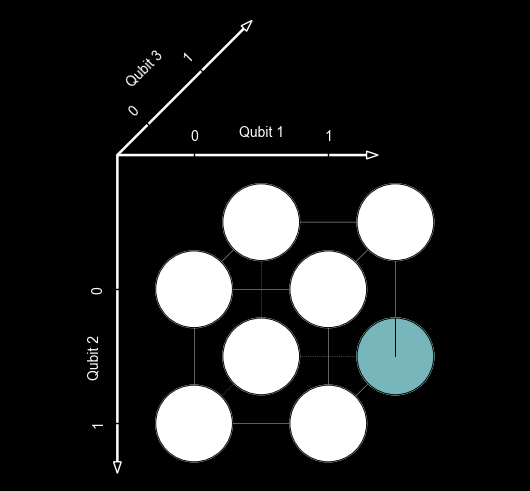


[NOISE] Oh no! A Bit-flip error occurred on Qubit 3!
--- Step 2: Corrupted State ---


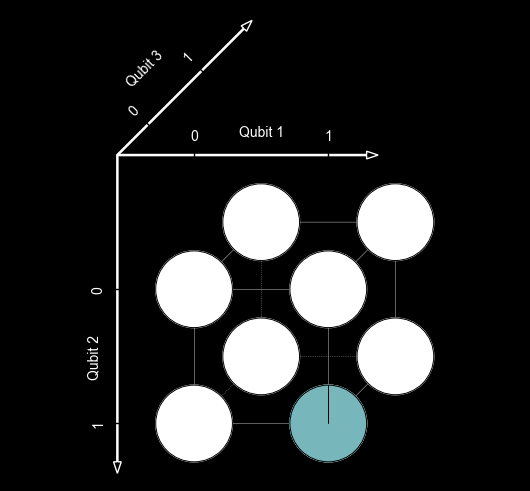

--- Step 3: Corrected State (Restored to |100>) ---
Note: The data is safely back on the first circle (Qubit 1)!
The other two circles (Qubits 2 & 3) now hold the 'Syndrome' (error info).


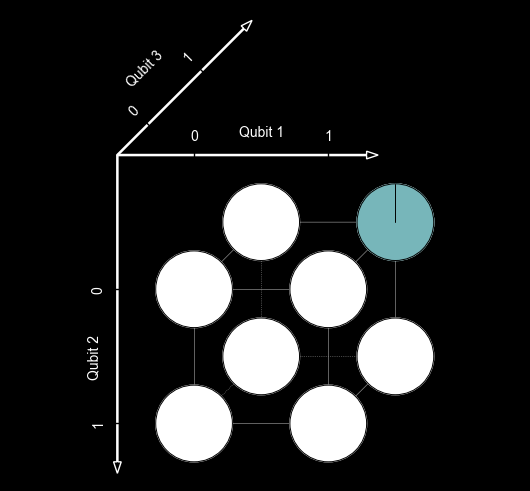


Final Circuit Diagram:


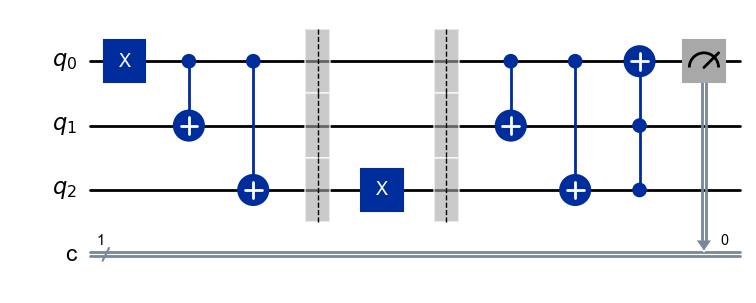

In [3]:
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Custom Visualization
from qc_education_package import DimensionalCircleNotation

def run_error_correction_demo(visualize=False):
    """
    Demonstrates a 3-qubit Repetition Code to protect the state |1>.
    """
    # We use 3 physical qubits to represent 1 logical qubit.
    # We also need 1 classical bit for the final readout.
    qc = QuantumCircuit(3, 1)

    # --- STEP 1: ENCODING ---
    # We want to protect the state |1>.
    # Protocol: Logical |1> = |111> (Bit-flip code)

    # 1. Prepare data qubit (Qubit 1) in state |1>
    qc.x(0)

    # 2. "Spread" the information (Entangle)
    # If Q1 is 1, flip Q2 and Q3 to 1.
    # This creates the state |111> (or |000> if Q0 was 0)
    qc.cx(0, 1)
    qc.cx(0, 2)

    if visualize:
        print("\n--- Step 1: Encoded State (Logical |1> as |111>) ---")
        DimensionalCircleNotation.from_qiskit(qc).show()

    qc.barrier()

    # --- STEP 2: NOISE ORACLE ---
    # Randomly flip one qubit (0, 1, 2) or None.
    error_loc = random.choice([0, 1, 2, None])

    if error_loc is not None:
        print(f"\n[NOISE] Oh no! A Bit-flip error occurred on Qubit {error_loc+1}!")
        qc.x(error_loc)
    else:
        print("\n[NOISE] Lucky! No error occurred.")

    if visualize:
        print(f"--- Step 2: Corrupted State ---")
        # Decompose ensures DCN can read the circuit even if we used custom gates
        DimensionalCircleNotation.from_qiskit(qc.decompose()).show()

    qc.barrier()

    # --- STEP 3: DECODING & CORRECTION ---
    # We need to determine if an error occurred without destroying the data.
    # We do this by un-computing the parity.

    # 1. Reverse the encoding CNOTs
    qc.cx(0, 1)
    qc.cx(0, 2)

    # ANALYSIS OF STATE NOW:
    # If state was |111> (No Error) -> CNOTs make it |100>
    # If state was |011> (Error on 1) -> CNOTs make it |011> (Q1, Q3 are 1!)
    # If state was |101> (Error on 2) -> CNOTs make it |110> (Q2 is 1)
    # If state was |110> (Error on 3) -> CNOTs make it |101> (Q3 is 1)

    # 2. MAJORITY VOTE (The Correction)
    # If both Q2 and Q3 are 1, it implies Q1 is the "odd one out" (the error).
    # We use a Toffoli (CCX) gate to flip Q1 back if Q2=1 and Q3=1.
    qc.ccx(1, 2, 0)

    if visualize:
        print(f"--- Step 3: Corrected State (Restored to |100>) ---")
        print("Note: The data is safely back on the first circle (Qubit 1)!")
        print("The other two circles (Qubits 2 & 3) now hold the 'Syndrome' (error info).")
        DimensionalCircleNotation.from_qiskit(qc.decompose()).show()

    # --- STEP 4: MEASUREMENT ---
    # We measure Qubit 1 to see if our data survived.
    qc.measure(0, 0)

    return qc

# --- RUN THE DEMO ---

# 1. Run a batch to check robustness
print("--- Batch Testing (10 Runs) ---")
sim = AerSimulator()
success_count = 0
for i in range(10):
    # Run without visualization for the batch
    qc = run_error_correction_demo(visualize=False)
    # NEW (Fixed)
    result = sim.run(transpile(qc, sim), shots=1, memory=True).result()
    if result.get_memory()[0] == "1":
        success_count += 1

print(f"Batch Result: {success_count}/10 measurements successfully recovered the state |1>.")

# 2. Run Single Detailed Visualization
print("\n" + "="*50)
print("VISUALIZATION DEEP DIVE")
print("="*50)
qc_vis = run_error_correction_demo(visualize=True)

print("\nFinal Circuit Diagram:")
display(qc_vis.draw(output="mpl"))
plt.close('all')

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your task: implement the same protocol to protect against phase flips.
</div>

## 9.3. Conclusion and Outlook

You have reached the end of this introductory course on Quantum Information.

We started with the **Bit**, moving to the **Qubit** and the **Bloch Sphere**. We visualized how single qubits behave under rotation and how **Superposition** allows them to hold complex amplitudes. We then combined qubits to discover **Entanglement**, a correlation stronger than anything possible in the classical world, and used it to **Teleport** information and code continuously using **Superdense Coding**.

Finally, we looked at the horizon:
* **Algorithms** like Deutsch show us *why* we build these machines: to solve problems in fewer steps than classical physics allows.
* **Error Correction** shows us *how* we will build them: by weaving many fragile physical qubits into robust logical fabrics.

### Where to go from here?
The journey is just beginning. To deepen your knowledge, consider exploring:

1. **Other quantum algorithms:** For example, Grover's algorithm searches in solution spaces in only $O(\sqrt{n})$, faster than the classical $O(n)$. Or Shor's algorithm, which breaks RSA encryption by helping with factorization of prime numbers via Quantum Fourier Transformation.
2. **Variational Quantum Eigensolvers (VQE):** Using quantum computers to simulate chemistry and molecules.
3.  **Hardware Implementations:** Learning how Superconducting Transmons or Trapped Ions actually work.

Having reached the end of this course, we would greatly appreciate it if you could fill out the following survey: https://forms.gle/FQo587RCB5DxJETT8

Thank you very much for participating!